# Sentiment Analysis of Social Media Posts
Fine-tuning transformer models for NLP classification tasks. The main task is to classify tweets into 3 sentiment categories: positive, negative and neutral, applying the principle of Transfer Learning

In [ ]:
# All libraries and dependencies utilised
from datasets import load_dataset, Dataset, DatasetDict
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns

# Loading, Exploring and Understanding the dataset

In [ ]:
# Load the TweetEval sentiment dataset
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
label_map = {0: "negative", 1: "neutral", 2: "positive"}

# Inspect dataset
print("Dataset: ", dataset)
print("Dataset Splits: ", dataset.keys())
print("dataset shape: ", dataset.shape)
print("label map: ", label_map)
print("Sample Tweet: ", dataset['train'][0])

Dataset:  DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Dataset Splits:  dict_keys(['train', 'test', 'validation'])
dataset shape:  {'train': (45615, 2), 'test': (12284, 2), 'validation': (2000, 2)}
label map:  {0: 'negative', 1: 'neutral', 2: 'positive'}
Sample Tweet:  {'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}


The dataset is already pre-split into train, test and validation sets. Each sample has a text/tweet and its corresponding label (negative=0, neutral=1 and positive=2)

# Visualise a subset of the text examples with their corresponding labels

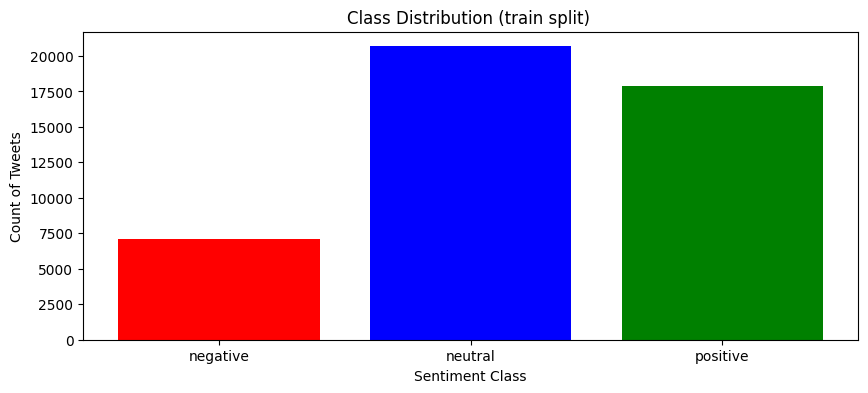

A set of sampled tweets from the Training Dataset:
                                                                                                                                text    label
                              I forgot all about Ice Cube being in the movie First Sunday. I think I seen this shit in the theaters. negative
playoffs are finally set. Chardon plays warren howland in the 1st round. if we win\u002c we play the winner of kenston v. tallmadge.  neutral
       Are we just going to ignore the fact that Ice Cube got his ass whoop by Ricky Smiley at the beginning of Friday After Next???  neutral
If you live in the South Orlando area\u002c be on the lookout. @user has its 6th site opening on October 30th near the Florida Mall!  neutral
                     First record of Colin Baker at the BBC: BBC2 serial The Roads to Freedom. Part 5 - shown 1 Nov 1970. #DoctorWho  neutral
                  Tomorrow night I'll be at Citi Field with the Zac Brown Band.  Anyone want to h

In [ ]:
# convert training subset into a dataframe
df1=pd.DataFrame(dataset['train'])

counts = df1["label"].value_counts().sort_index()
labels = [label_map[i] for i in counts.index]

plt.figure(figsize=(10, 4))
plt.bar(labels, counts.values, color=["red", "blue", "green"])
plt.title("Class Distribution (train split) ")
plt.ylabel("Count of Tweets")
plt.xlabel("Sentiment Class")
plt.show()

# display a subset of some tweets
samp_tweets=df1[["text", "label"]].sample(8, random_state=42)

# making numeric labels readable
samp_tweets["label"]=samp_tweets["label"].map(label_map)

print("A set of sampled tweets from the Training Dataset:")
print(samp_tweets.to_string(index=False))

1. In the class distribution bar graph, you notice an obvious imbalance, with the neutral labels (45%) dominating the pack. There are lower negative labels (16%)compared to positive ones (39%)
2. Output below shows a clear visual of 8 sampled tweets, with their associated labels. The tweets are noisy, with URLs, jargon and mentions

# Sub sampling by splitting the dataset into training, validating and testing sets

1. Maintains class proportions across those splits
2. Ensures models can train on the same 20000 examples
3. To address computational restraints

This sets a good tone for comparative analysis

In [ ]:
# Subsample 20,000 training samples
train_df1 = pd.DataFrame(dataset["train"])
sub_train_df, _ = train_test_split(
    train_df1,
    train_size=20000,
    stratify=train_df1["label"],
    random_state=42
)

# Convert back to Dataset objects
sub_dataset = DatasetDict({
    "train": Dataset.from_pandas(sub_train_df.reset_index(drop=True)),
    "validation": dataset["validation"],
    "test": dataset["test"]
})

# Training and Fine-tuning
Transformer models selected are as follows:

1. BERT (Bidirectional Encoder Representations from Transformers) - bert-base-uncased
2. RoBERTa/twitter-RoBERTa - cardiffnlp/twitter-roberta-base
3. DistilBERT - distilbert-base-uncased

In [ ]:
# compute weights based on your training data distribution to address class imbalance
train_labels = sub_dataset['train']['label']
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In this section, we emphasise how much attention to give to the minority classes by calculating weights. Minority classes receive larger weights while majority receive fewer weights

In [ ]:
# Shared label maps
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

# Shared WeightedTrainer to handle imbalance
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In this section I created a WeightedTrainer class to modify the model calculations of loss, so that the models do not become biased toward the majority sentiment class.

1. compute_loss() calculates the models error during training. Its customised loss function penalises the bias towards majority sentiment classes more heavily. Helps the models learn from the dataset in a balanced manner.

In [ ]:
def compute_metrics(eval_pred): # converts model's raw outputs into human readable metrics
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro")
    }

1. compute_metrics() defines how the models are evaluated

# Model 1: twitter-RoBERTa

In [ ]:
rob_model="cardiffnlp/twitter-roberta-base" # base model

rob_tokenizer = AutoTokenizer.from_pretrained(rob_model)

def rob_tokenize_fn(batch):
    return rob_tokenizer(batch["text"], max_length=128, truncation=True)

rob_tokenized_ds = sub_dataset.map(rob_tokenize_fn, batched=True)
rob_collator = DataCollatorWithPadding(tokenizer=rob_tokenizer) # handle the padding during training

rob_model_= AutoModelForSequenceClassification.from_pretrained(
    rob_model,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

rob_args = TrainingArguments(
    output_dir="./results_twitter_roberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer_rob = WeightedTrainer(
    model=rob_model_,
    args=rob_args,
    train_dataset=rob_tokenized_ds["train"],
    eval_dataset=rob_tokenized_ds["validation"],
    compute_metrics=compute_metrics,
    data_collator=rob_collator
)

trainer_rob.train()

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3750, training_loss=0.5694336303710937, metrics={'train_runtime': 688.5856, 'train_samples_per_second': 87.135, 'train_steps_per_second': 5.446, 'total_flos': 1343021329321056.0, 'train_loss': 0.5694336303710937, 'epoch': 3.0})

# Model 2: BERT-base

In [ ]:
bert_model="google-bert/bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model)

def bert_tokenize_fn(batch):
    return bert_tokenizer(batch["text"], max_length=128, truncation=True)

bert_tokenized_ds = sub_dataset.map(bert_tokenize_fn, batched=True)
bert_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

bert_model_= AutoModelForSequenceClassification.from_pretrained(
    bert_model,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

bert_args = TrainingArguments(
    output_dir="./results_bert_base",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

trainer_bert = WeightedTrainer(
    model=bert_model_,
    args=bert_args,
    train_dataset=bert_tokenized_ds["train"],
    eval_dataset=bert_tokenized_ds["validation"],
    compute_metrics=compute_metrics,
    data_collator=bert_collator
)

trainer_bert.train()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3750, training_loss=0.540433935546875, metrics={'train_runtime': 848.4329, 'train_samples_per_second': 70.719, 'train_steps_per_second': 4.42, 'total_flos': 1412820385667712.0, 'train_loss': 0.540433935546875, 'epoch': 3.0})

# Model 3: DistilBERT

In [ ]:
distil_model="distilbert-base-uncased"

distil_tokenizer = AutoTokenizer.from_pretrained(distil_model)

def distil_tokenize_fn(batch):
    return distil_tokenizer(batch["text"], max_length=128, truncation=True)

distil_tokenized_ds = sub_dataset.map(distil_tokenize_fn, batched=True)
distil_collator = DataCollatorWithPadding(tokenizer=distil_tokenizer)

distil_model_= AutoModelForSequenceClassification.from_pretrained(
    distil_model,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

distil_args = TrainingArguments(
    output_dir="./results_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5, # a little bit higher to compensate for its size
    per_device_train_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

trainer_distil = WeightedTrainer(
    model=distil_model_,
    args=distil_args,
    train_dataset=distil_tokenized_ds["train"],
    eval_dataset=distil_tokenized_ds["validation"],
    compute_metrics=compute_metrics,
    data_collator=distil_collator
)

trainer_distil.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2500, training_loss=0.49436754150390627, metrics={'train_runtime': 562.5474, 'train_samples_per_second': 142.21, 'train_steps_per_second': 4.444, 'total_flos': 1026243238652928.0, 'train_loss': 0.49436754150390627, 'epoch': 4.0})

In [ ]:
# Generating Predictions
preds_rob = trainer_rob.predict(rob_tokenized_ds["test"])
preds_bert = trainer_bert.predict(bert_tokenized_ds["test"])
preds_distil = trainer_distil.predict(distil_tokenized_ds["test"])

y_true = sub_dataset["test"]["label"] # True labels
# Predicted labels
y_pred_rob = np.argmax(preds_rob.predictions, axis=1)
y_pred_bert = np.argmax(preds_bert.predictions, axis=1)
y_pred_distil = np.argmax(preds_distil.predictions, axis=1)

# Evaluate Models
results_rob = preds_rob.metrics
results_bert = preds_bert.metrics
results_distil = preds_distil.metrics

#Evaluating all models on considered metrics

For each model the following metrics were selected and justified as potent metrics below:

1. Macro F1 - Provides the average F1 score across all the three classes. Does well to penalise the models when the minority classes are ignored. This is an important metric to explore, given the nature of the imbalanced dataset
2. Per Class F1 Score - Reflects the overall prediction quality
Per-class F1 score - Shows where each model struggles specifically
3. Confusion Matrices - to reveal systematic misclassification patterns.

In [ ]:
# Classification Reports for all models
report_rob = classification_report(
    y_true, y_pred_rob,
    target_names=list(label2id.keys())
)
print("twitter-RoBERTa Classification Report")
print(report_rob)

report_bert = classification_report(
    y_true, y_pred_bert,
    target_names=list(label2id.keys())

)
print("BERT-base Classification Report")
print(report_bert)

report_distil = classification_report(
    y_true, y_pred_distil,
    target_names=list(label2id.keys())
)
print("DistilBERT Classification Report")
print(report_distil)

twitter-RoBERTa Classification Report
              precision    recall  f1-score   support

    negative       0.66      0.86      0.74      3972
     neutral       0.78      0.55      0.65      5937
    positive       0.64      0.78      0.71      2375

    accuracy                           0.70     12284
   macro avg       0.69      0.73      0.70     12284
weighted avg       0.71      0.70      0.69     12284

BERT-base Classification Report
              precision    recall  f1-score   support

    negative       0.67      0.78      0.72      3972
     neutral       0.73      0.61      0.67      5937
    positive       0.64      0.74      0.68      2375

    accuracy                           0.69     12284
   macro avg       0.68      0.71      0.69     12284
weighted avg       0.70      0.69      0.69     12284

DistilBERT Classification Report
              precision    recall  f1-score   support

    negative       0.65      0.77      0.70      3972
     neutral       0.72   

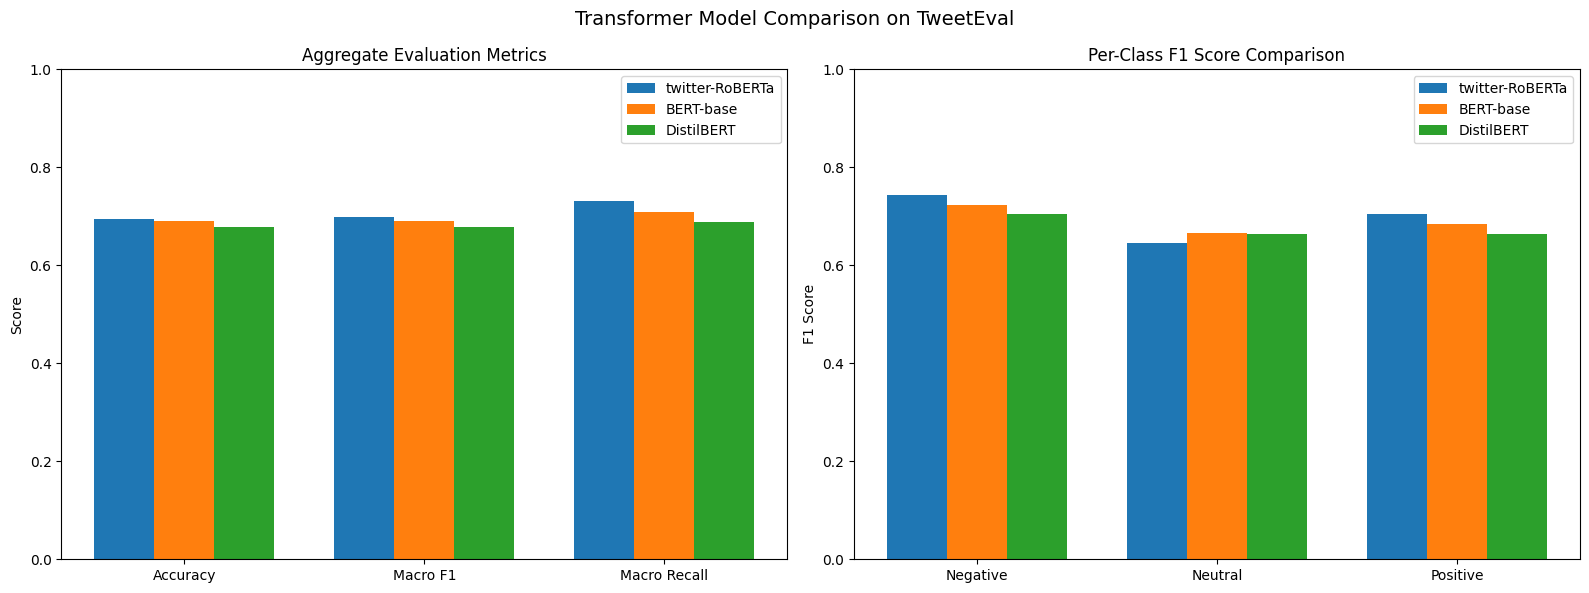

In [ ]:
# Aggregate Metrics
metrics = ["Accuracy", "Macro F1", "Macro Recall"]

rob_vals = [
    accuracy_score(y_true, y_pred_rob),
    f1_score(y_true, y_pred_rob, average="macro"),
    recall_score(y_true, y_pred_rob, average="macro")
]

bert_vals = [
    accuracy_score(y_true, y_pred_bert),
    f1_score(y_true, y_pred_bert, average="macro"),
    recall_score(y_true, y_pred_bert, average="macro")
]

distil_vals = [
    accuracy_score(y_true, y_pred_distil),
    f1_score(y_true, y_pred_distil, average="macro"),
    recall_score(y_true, y_pred_distil, average="macro")
]

report_rob_   = classification_report(y_true, y_pred_rob,   target_names=class_labels, output_dict=True)
report_bert_  = classification_report(y_true, y_pred_bert,  target_names=class_labels, output_dict=True)
report_distil_ = classification_report(y_true, y_pred_distil, target_names=class_labels, output_dict=True)

# Per-Class F1 Scores

class_labels = list(label_map.values())

rob_f1   = [report_rob_[label]["f1-score"]   for label in class_labels]
bert_f1  = [report_bert_[label]["f1-score"]  for label in class_labels]
distil_f1 = [report_distil_[label]["f1-score"] for label in class_labels]


# Create Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

width = 0.25

# aggregate metrics

x1 = np.arange(len(metrics))

axes[0].bar(x1 - width, rob_vals, width, label='twitter-RoBERTa')
axes[0].bar(x1, bert_vals, width, label='BERT-base')
axes[0].bar(x1 + width, distil_vals, width, label='DistilBERT')

axes[0].set_xticks(x1)
axes[0].set_xticklabels(metrics)

axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_title("Aggregate Evaluation Metrics")

axes[0].legend()


# Plot per class F1 scores

x2 = np.arange(len(class_labels))

axes[1].bar(x2 - width, rob_f1, width, label='twitter-RoBERTa')
axes[1].bar(x2, bert_f1, width, label='BERT-base')
axes[1].bar(x2 + width, distil_f1, width, label='DistilBERT')

axes[1].set_xticks(x2)

axes[1].set_xticklabels(
    [label.capitalize() for label in class_labels]
)

axes[1].set_ylim(0, 1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score Comparison")

axes[1].legend()

plt.suptitle(
    "Transformer Model Comparison on TweetEval",
    fontsize=14
)

plt.tight_layout()
plt.show()

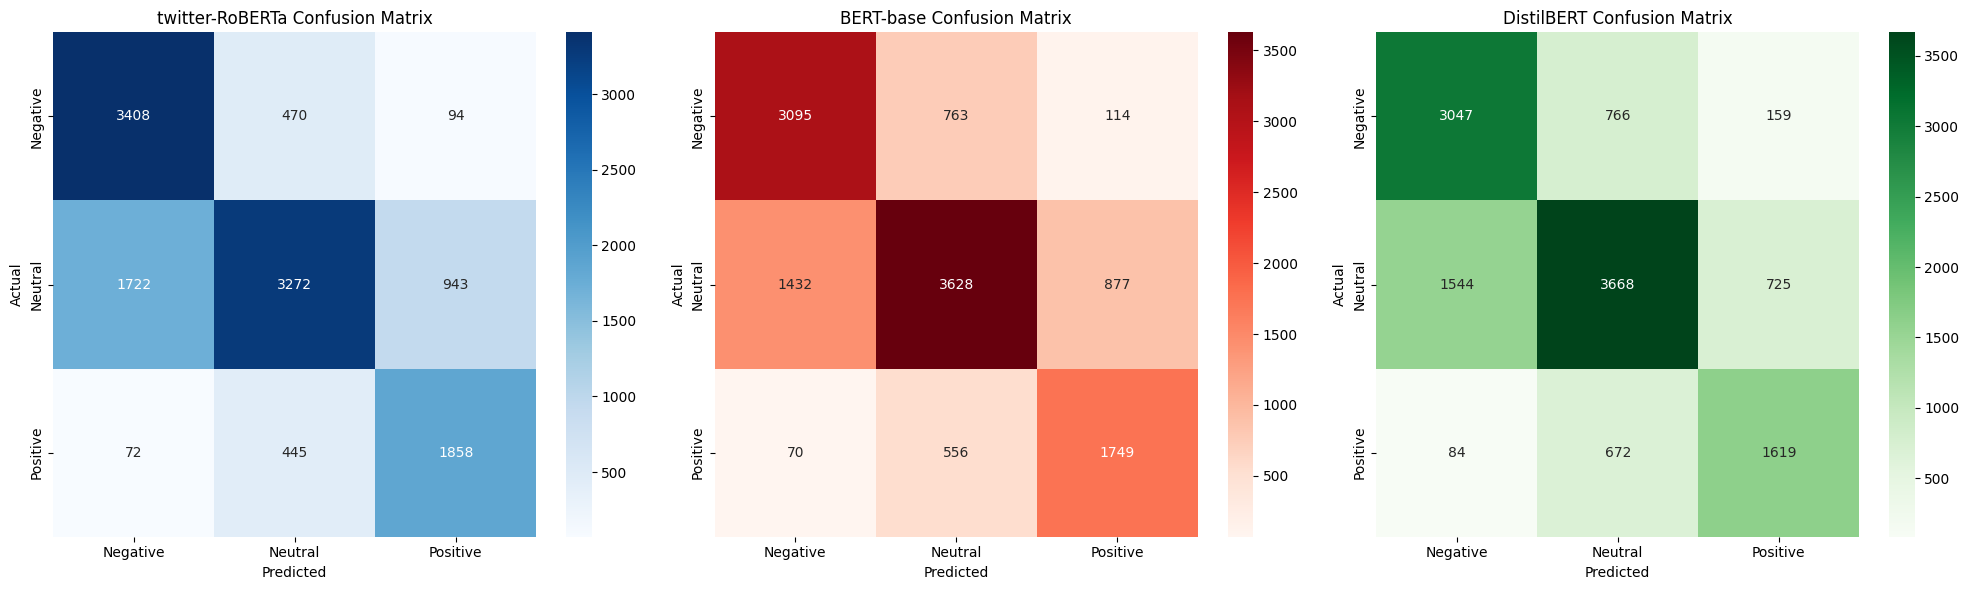

In [ ]:
def plot_all_confusion_matrices(y_true, y_pred_rob, y_pred_bert, y_pred_distil):
    # Use pre-computed predictions from the evaluation cell (avoids redundant inference)

    # Create the Confusion Matrices
    cm_rob = confusion_matrix(y_true, y_pred_rob)
    cm_bert = confusion_matrix(y_true, y_pred_bert)
    cm_distil = confusion_matrix(y_true, y_pred_distil)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    # Use title-cased versions of label_map values for display
    labels = [v.capitalize() for v in label_map.values()]

    # Plot RoBERTa
    sns.heatmap(cm_rob, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_title("twitter-RoBERTa Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # Plot BERT
    sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds', ax=axes[1],
                xticklabels=labels, yticklabels=labels)
    axes[1].set_title("BERT-base Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    # Plot DistilBERT
    sns.heatmap(cm_distil, annot=True, fmt='d', cmap='Greens', ax=axes[2],
                xticklabels=labels, yticklabels=labels)
    axes[2].set_title("DistilBERT Confusion Matrix")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

# Run the comparison using already-computed predictions
plot_all_confusion_matrices(y_true, y_pred_rob, y_pred_bert, y_pred_distil)

1. twitter-RoBERTa shows stronger classification performance between the negative
and positive classes. Also shows the lowest confusion in the off-diagonal areas across board but struggles with the neutral class.
2. BERT follows a similar pattern, but has higher misclassification values than twitter-RoBERTa
3. DistilBERT recognises the neutral class the most in comparison, but has the highest misclassification rates in the off-diagonal regions, across the board. Records lower neutral-negative and neutral-positive counts

# Summary and Conclusion

1. twitter-RoBERTa generalises most effectively across the imbalance sentiment classes, while maintaining a balanced predictive ability. Domain specifi transformer model lie it outperform general purpose baselines on twitter data given their exposure to twitter language, which contain abbreviations, jargons, hashtags and mentions.
2. DistilBERT could be a suitable baseline if our goal is to identify neutral tweets accurately in , say, public discourse on social media.